In [3]:
import sys,os

from qiskit import BasicAer,execute
backend = BasicAer.get_backend("dm_simulator")

# Get the absolute path of the project's root directory
cd = os.path.abspath(os.path.join(os.path.dirname("qsim-superstaq"), '..'))

# Add the utils and models directories to sys.path
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks/supermarq/benchmarks'))
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks/supermarq'))
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks'))

from plotting import *
from converters import *
from benchmarks import GHZ, HamiltonianSimulation, MerminBell, QAOAFermionicSwapProxy, QAOAVanillaProxy, VQEProxy
import time
from numpy import mean
import resource

In [2]:
def run(benchmark_class,min_qubits,max_qubits,num_ckts,name,noise):
    data = {}
    creation_times = []
    execution_times = []
    quantum_times = []
    features_set = []
    scores = []
    memory = []
    options = noise
    for qubits in range(min_qubits,max_qubits+1):
        print("****************************************************")
        print( f"Executing {num_ckts} circuits with {qubits} qubits")
        circuit_name = f"{name}-{qubits}"
        
        for ckt in range(num_ckts):
            # start execution for each circuit
            benchmark_obj = benchmark_class(qubits)
            # Calculate Creation time 
            t_c = time.time()
            qc= benchmark_obj.qiskit_circuit()
            creation_time = time.time()-t_c  #in sec
            creation_times.append(creation_time)
            #print(qc)
    
            # Calculate Execution time 
            t_e = time.time()
            job = execute(qc, backend,**options)
            result = job.result()
            execution_time = time.time() - t_e #in sec
        
            # Calculate quantum processing time 
            quantum_time = (result.time_taken) #in sec
            execution_times.append(execution_time)
            quantum_times.append(quantum_time)
            
            #Calculate score of the fidelity
            counts = result.results[0].data.partial_probability
            #print("counts : ",counts)
            score = benchmark_obj.score(counts)
            #print("Score : ",score)
            scores.append(score)

            features = [
            compute_communication_with_qiskit(qc),
            compute_depth_with_qiskit(qc),
            compute_entanglement_with_qiskit(qc),
            compute_liveness_with_qiskit(qc),
            compute_measurement_with_qiskit(qc),
            compute_parallelism_with_qiskit(qc),
            ]
            features_set.append(features)
            #print("Features :",features)

            usage = resource.getrusage(resource.RUSAGE_SELF)
            max_mem = usage.ru_maxrss/1000 #in MB
            memory.append(max_mem)
            
        #average values calculation
        print(f"Average result of {num_ckts} circuits of {qubits} qubits are:") 
        creation_time, execution_time, quantum_time = mean(creation_times),mean(execution_times), mean(quantum_times)
        print(f"Creation, execution and Quantum Times = {creation_time},{execution_time} & {quantum_time} seconds")
        Features = list(mean(features_set, axis=0))
        print(f"Features of {qubits}-qubit circuits: {Features}")
        score = mean(scores)
        print(f"SCORE = {score}")
        memory_utilization = max(memory)
        print(f" Peak Memory Utilized = {memory_utilization} MB\n")
        print("****************************************************")

        data[circuit_name]={'creation_time':creation_time,'execution_time': execution_time,'quantum_time': quantum_time,'score':score,'Features':Features,'Memory':memory_utilization}
    print("data = ",data)
    return data    

In [3]:
def get_fidelity_plots(data):
    #score plots
    circuits = list(data.keys())
    scores = []
    features_set=[]
    for i in list(data.values()):
        scores.append(i['score'])
        features_set.append(i['Features'])
    plot_results(scores,circuits)

In [4]:
options={}

options_noisy = { #if Noise is not None
    'plot': False,
    'show_partition': False,
    "decoherence_factor": 0.9,
    "depolarization_factor": 0.9,
}

# GHZ:

****************************************************
Executing 1 circuits with 3 qubits
Average result of 1 circuits of 3 qubits are:
Creation, execution and Quantum Times = 0.00019884109497070312,0.0754084587097168 & 0.0008502006530761719 seconds
Features of 3-qubit circuits: [0.6666666666666666, 1.0, 0.6666666666666666, 0.6666666666666666, 0.0, 0.0]
SCORE = 1.0
 Peak Memory Utilized = 257.828 MB

****************************************************
****************************************************
Executing 1 circuits with 4 qubits
Average result of 1 circuits of 4 qubits are:
Creation, execution and Quantum Times = 0.00016415119171142578,0.03977859020233154 & 0.0013707876205444336 seconds
Features of 4-qubit circuits: [0.5833333333333333, 1.0, 0.7083333333333333, 0.6083333333333334, 0.0, 0.0]
SCORE = 1.0
 Peak Memory Utilized = 257.828 MB

****************************************************
****************************************************
Executing 1 circuits with 5 qubits
A

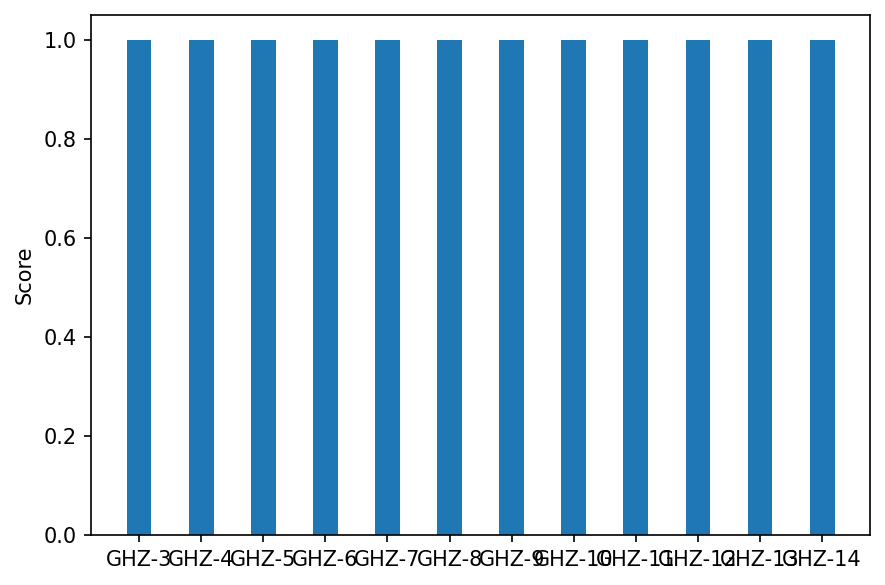

In [5]:
data = run(GHZ,min_qubits=3,max_qubits=14,num_ckts=1,name="GHZ",noise=options)
get_fidelity_plots(data)
# data_noisy = run(GHZ,min_qubits=3,max_qubits=8,num_ckts=2,name="GHZ",noise=options_noisy)
# get_fidelity_plots(data_noisy)

# Hamiltonian:

****************************************************
Executing 1 circuits with 3 qubits
Average result of 1 circuits of 3 qubits are:
Creation, execution and Quantum Times = 0.0002837181091308594,0.10973215103149414 & 0.002051830291748047 seconds
Features of 3-qubit circuits: [0.6666666666666666, 1.0, 0.26666666666666666, 0.7333333333333333, 0.0, 0.33333333333333337]
SCORE = 0.9999622344067259
 Peak Memory Utilized = 50717.712 MB

****************************************************
****************************************************
Executing 1 circuits with 4 qubits
Average result of 1 circuits of 4 qubits are:
Creation, execution and Quantum Times = 0.00030410289764404297,0.05899703502655029 & 0.002329707145690918 seconds
Features of 4-qubit circuits: [0.5833333333333333, 1.0, 0.2761904761904762, 0.6647435897435897, 0.0, 0.2916666666666667]
SCORE = 0.9999622344067258
 Peak Memory Utilized = 50717.712 MB

****************************************************
*************************

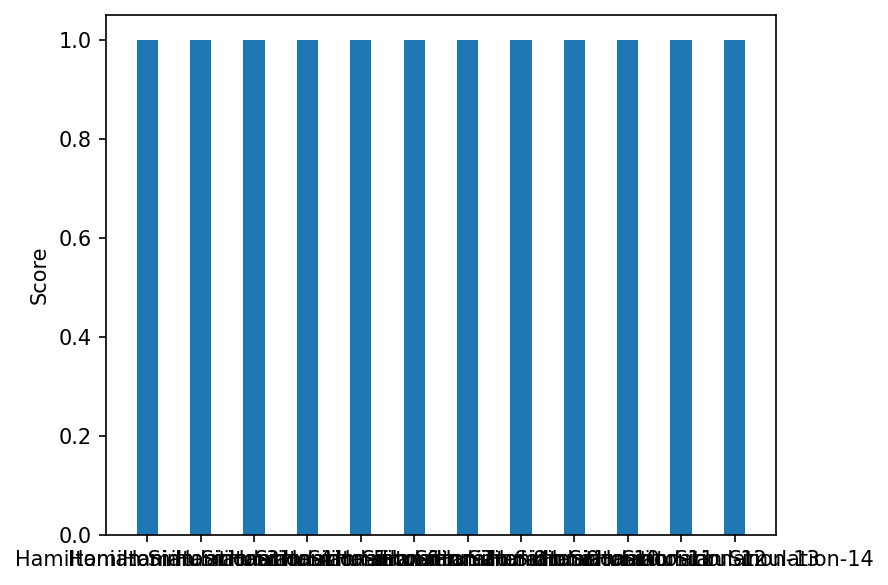

In [6]:
data = run(HamiltonianSimulation,min_qubits=3,max_qubits=14,num_ckts=1,name="Hamiltonian Simulation",noise=options)
get_fidelity_plots(data)
# data_noisy = run(HamiltonianSimulation,min_qubits=3,max_qubits=8,num_ckts=2,name="Hamiltonian Simulation",noise=options_noisy)
# get_fidelity_plots(data_noisy)

# Mermin Bell:

****************************************************
Executing 1 circuits with 3 qubits
Average result of 1 circuits of 3 qubits are:
Creation, execution and Quantum Times = 0.08995366096496582,0.006905555725097656 & 0.002341747283935547 seconds
Features of 3-qubit circuits: [1.0, 1.0, 0.4375, 0.6666666666666666, 0.0, 0.16666666666666663]
SCORE = 1.0
 Peak Memory Utilized = 50721.128 MB

****************************************************
****************************************************
Executing 1 circuits with 4 qubits
Average result of 1 circuits of 4 qubits are:
Creation, execution and Quantum Times = 0.06478464603424072,0.007891416549682617 & 0.003006577491760254 seconds
Features of 4-qubit circuits: [1.0, 0.9615384615384616, 0.47875, 0.625, 0.0, 0.16176470588235292]
SCORE = 1.0
 Peak Memory Utilized = 50721.128 MB

****************************************************
****************************************************
Executing 1 circuits with 5 qubits
Average result of 1 c

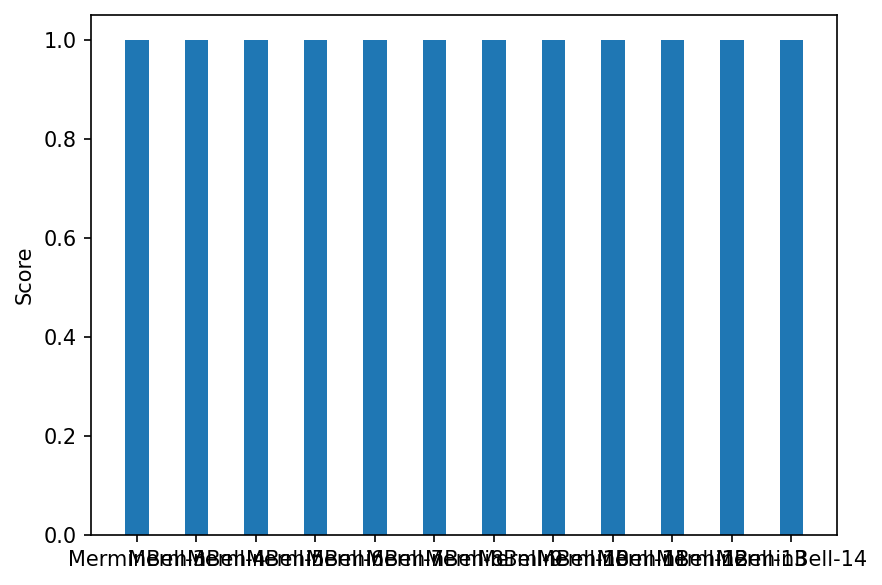

In [7]:
data = run(MerminBell,min_qubits=3,max_qubits=14,num_ckts=1,name="MerminBell",noise=options)
get_fidelity_plots(data)
# data_noisy = run(MerminBell,min_qubits=3,max_qubits=8,num_ckts=2,name="MerminBell",noise=options_noisy)
# get_fidelity_plots(data_noisy)

# QAOAFermonicsSwapProxy:

****************************************************
Executing 1 circuits with 3 qubits
Average result of 1 circuits of 3 qubits are:
Creation, execution and Quantum Times = 0.01851201057434082,0.006691455841064453 & 0.0025475025177001953 seconds
Features of 3-qubit circuits: [0.6666666666666666, 1.0, 0.5, 0.6666666666666666, 0.0, 0.1428571428571429]
SCORE = 0.9998779678101216
 Peak Memory Utilized = 50725.704 MB

****************************************************
****************************************************
Executing 1 circuits with 4 qubits
Average result of 1 circuits of 4 qubits are:
Creation, execution and Quantum Times = 0.018567204475402832,0.00762486457824707 & 0.003137826919555664 seconds
Features of 4-qubit circuits: [0.5833333333333333, 0.8333333333333333, 0.53125, 0.6885964912280702, 0.0, 0.20105820105820107]
SCORE = 0.9996930244027882
 Peak Memory Utilized = 50725.704 MB

****************************************************
***************************************

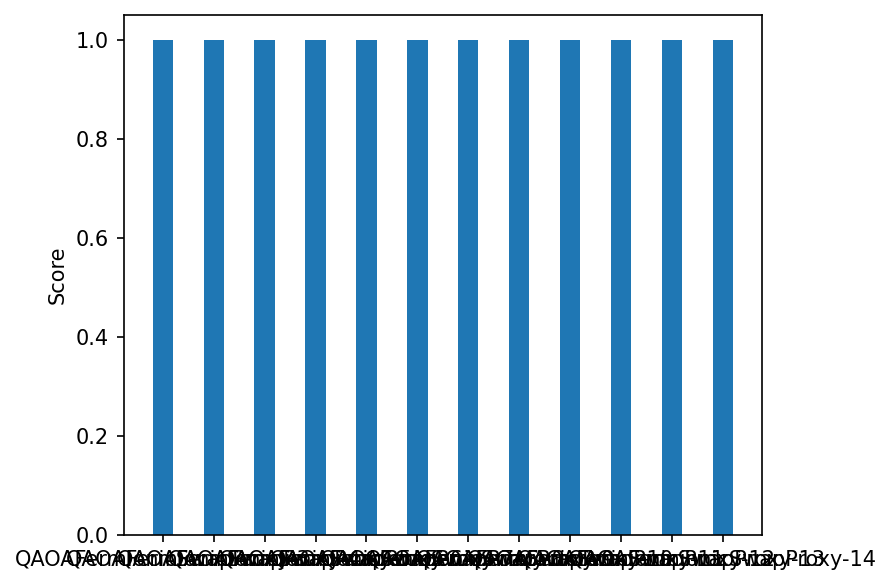

In [8]:
data = run(QAOAFermionicSwapProxy,min_qubits=3,max_qubits=14,num_ckts=1,name="QAOAFermionicSwapProxy",noise=options)
get_fidelity_plots(data)
# data_noisy = run(QAOAFermionicSwapProxy,min_qubits=3,max_qubits=8,num_ckts=2,name="QAOAFermionicSwapProxy",noise=options_noisy)
# get_fidelity_plots(data_noisy)

# QAOAVanillaProxy:

****************************************************
Executing 1 circuits with 3 qubits
Average result of 1 circuits of 3 qubits are:
Creation, execution and Quantum Times = 0.018060684204101562,0.006259441375732422 & 0.002293825149536133 seconds
Features of 3-qubit circuits: [1.0, 1.0, 0.4, 0.6666666666666666, 0.0, 0.18181818181818177]
SCORE = 0.9999999554665758
 Peak Memory Utilized = 50725.704 MB

****************************************************
****************************************************
Executing 1 circuits with 4 qubits
Average result of 1 circuits of 4 qubits are:
Creation, execution and Quantum Times = 0.017981529235839844,0.00714111328125 & 0.0027312040328979492 seconds
Features of 4-qubit circuits: [1.0, 0.8333333333333333, 0.4307692307692308, 0.6833333333333333, 0.0, 0.23376623376623376]
SCORE = 0.999754019500976
 Peak Memory Utilized = 50725.704 MB

****************************************************
****************************************************
Executi

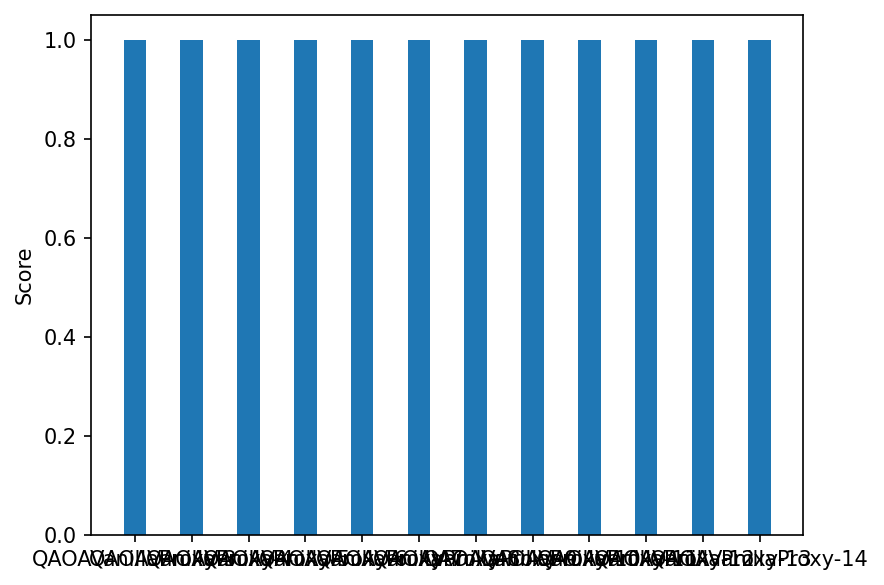

In [9]:
data = run(QAOAVanillaProxy,min_qubits=3,max_qubits=14,num_ckts=1,name="QAOAVanillaProxy",noise=options)
get_fidelity_plots(data)
# data_noisy = run(QAOAVanillaProxy,min_qubits=3,max_qubits=8,num_ckts=2,name="QAOAVanillaProxy",noise=options_noisy)
# get_fidelity_plots(data_noisy)

In [9]:
import simulation,time

def vqep(q):
    final_counts = []
    ckt_list = []
    exec_times = []
    quant_times = []
    
    # Calculate Creation time 
    t_c = time.time()
    #vqe = VQEProxy(3, 1) #3 Qubits, 1 Layer
    vqe = VQEProxy(q, 1)
    shots = 1000
    ckts =  vqe.circuit()
    creation_time = time.time()-t_c
    
    for i in ckts:
        ckt_list.append(cirq_to_qiskit(i))
    
    print(f" Creation time for {len(ckt_list)} circuits = {creation_time} sec")
    
    # for i in ckts:
    #     print(i)
    
    
    for i in ckt_list:
        # Calculate Execution time 
        t_e = time.time()
        job = execute(i, backend, shots=shots, **options)
        result = job.result()
        execution_time = time.time() - t_e #in sec
    
        # Calculate quantum processing time 
        quantum_time = (result.time_taken) #in sec
    
        #print(f" For circuit i, execution time = {execution_time} sec and quantum time = {quantum_time} sec")
        
        counts = result.results[0].data.partial_probability
        for key in counts.keys():
            counts[key] = int(counts[key] * shots)
    
        final_counts.append(counts)
        exec_times.append(execution_time)
        quant_times.append(quant_times)
    
    print("Final Counts:",final_counts)
    print("########################################################")
    print(f"execution time, quantum time = {sum(exec_times)},{sum(quant_times)}") 
    score_vqe = vqe.score(final_counts)
    print(score_vqe)
    
    name = "VQE_Proxy"
    qubits = vqe.num_qubits
    
    benchmark_name = f"{name}-{qubits}"
    plot_results([score_vqe],[benchmark_name])
    
    # for i in ckt_list:
    #     features = [
    #     compute_communication_with_qiskit(i),
    #     compute_depth_with_qiskit(i),
    #     compute_entanglement_with_qiskit(i),
    #     compute_liveness_with_qiskit(i),
    #     compute_measurement_with_qiskit(i),
    #     compute_parallelism_with_qiskit(i),
    #     ]
    #     print(f"Features for ckt {i.name}: {features}")
        
    #     plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
    #                        spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )

for i in range(3,15):
    vqep(i)

 Creation time for 2 circuits = 3.9551408290863037 sec
Final Counts: [{'000': 800, '001': 56, '010': 56, '011': 12, '100': 58, '101': 4, '110': 10, '111': 0}, {'000': 460, '001': 132, '010': 115, '011': 50, '100': 136, '101': 35, '110': 45, '111': 23}]
########################################################


TypeError: unsupported operand type(s) for +: 'int' and 'list'

 For circuit i=circuit-840, execution time = 0.0067806243896484375 sec and quantum time = 0.0010938644409179688 sec
 For circuit i=circuit-842, execution time = 0.00738835334777832 sec and quantum time = 0.0014300346374511719 sec
Final Counts: [{'000': 799, '001': 57, '010': 57, '011': 14, '100': 61, '101': 3, '110': 3, '111': 3}, {'000': 458, '001': 115, '010': 115, '011': 65, '100': 143, '101': 42, '110': 42, '111': 15}]
for 2 circuits of 3 qubits Creation time = 4.029789686203003 sec, Execution time = 0.014168977737426758 sec and quantum time = 0.0025238990783691406 sec
0.9983226895979125


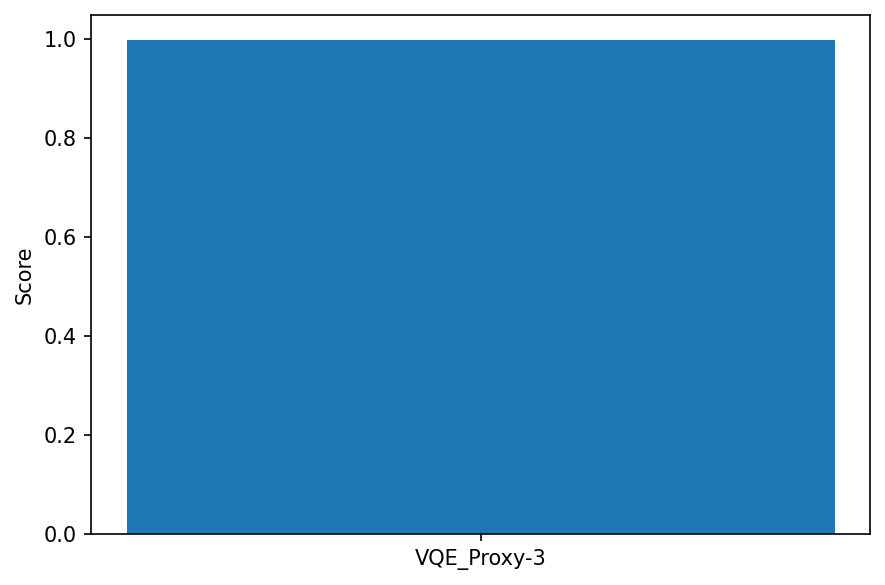

########################################################
 For circuit i=circuit-901, execution time = 0.011165380477905273 sec and quantum time = 0.003854036331176758 sec
 For circuit i=circuit-903, execution time = 0.009458780288696289 sec and quantum time = 0.003278970718383789 sec
Final Counts: [{'0000': 0, '0001': 0, '0010': 0, '0011': 4, '0100': 0, '0101': 3, '0110': 3, '0111': 54, '1000': 0, '1001': 4, '1010': 3, '1011': 54, '1100': 12, '1101': 53, '1110': 52, '1111': 749}, {'0000': 337, '0001': 94, '0010': 91, '0011': 43, '0100': 109, '0101': 30, '0110': 31, '0111': 14, '1000': 111, '1001': 30, '1010': 30, '1011': 14, '1100': 36, '1101': 10, '1110': 10, '1111': 4}]
for 2 circuits of 4 qubits Creation time = 5.219797372817993 sec, Execution time = 0.020624160766601562 sec and quantum time = 0.007133007049560547 sec
0.9956384381035142


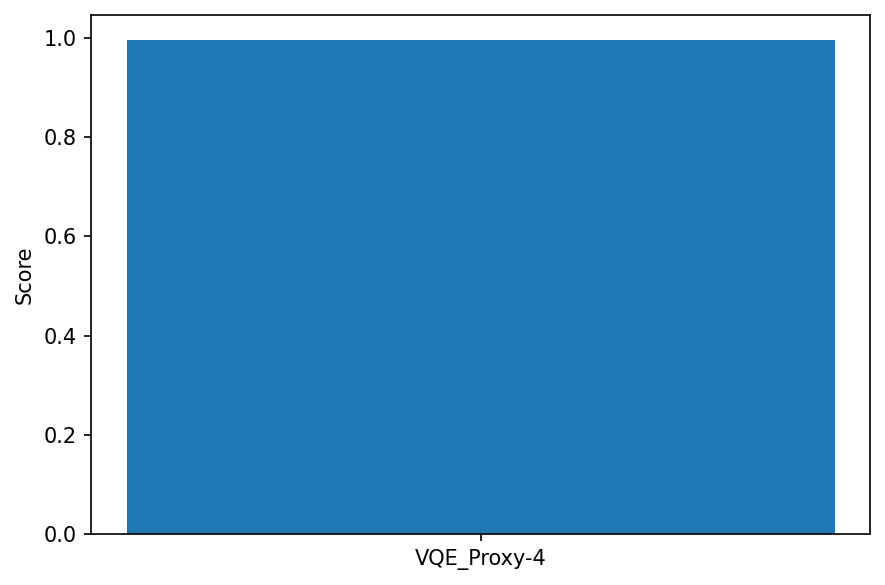

########################################################
 For circuit i=circuit-978, execution time = 0.015315055847167969 sec and quantum time = 0.008199691772460938 sec
 For circuit i=circuit-980, execution time = 0.015541315078735352 sec and quantum time = 0.008415937423706055 sec
Final Counts: [{'00000': 0, '00001': 0, '00010': 0, '00011': 0, '00100': 0, '00101': 0, '00110': 0, '00111': 3, '01000': 0, '01001': 0, '01010': 0, '01011': 3, '01100': 0, '01101': 3, '01110': 3, '01111': 50, '10000': 0, '10001': 0, '10010': 0, '10011': 3, '10100': 0, '10101': 3, '10110': 3, '10111': 50, '11000': 0, '11001': 10, '11010': 4, '11011': 49, '11100': 12, '11101': 47, '11110': 48, '11111': 694}, {'00000': 264, '00001': 73, '00010': 63, '00011': 28, '00100': 76, '00101': 19, '00110': 26, '00111': 14, '01000': 86, '01001': 24, '01010': 20, '01011': 9, '01100': 24, '01101': 6, '01110': 8, '01111': 4, '10000': 87, '10001': 24, '10010': 20, '10011': 9, '10100': 25, '10101': 6, '10110': 8, '10111': 4,

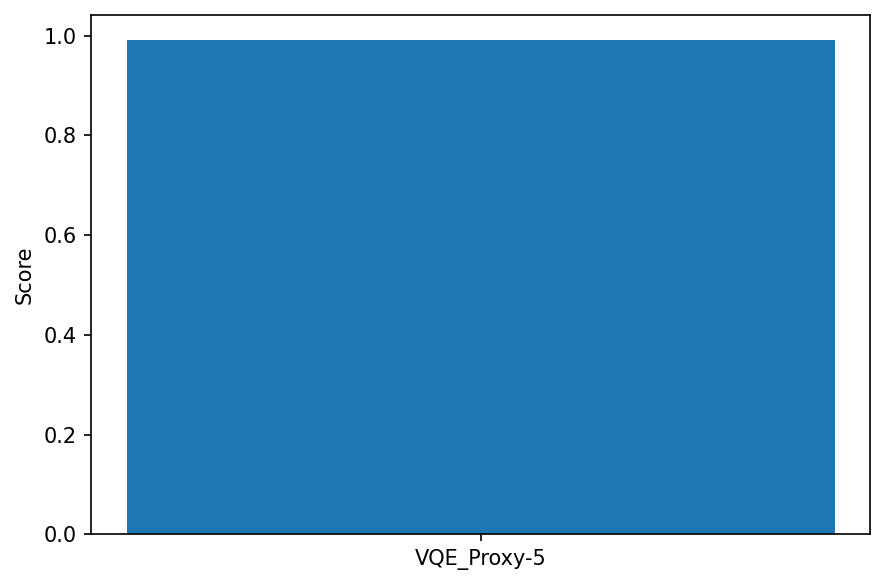

########################################################
 For circuit i=circuit-1071, execution time = 0.040198326110839844 sec and quantum time = 0.032636165618896484 sec
 For circuit i=circuit-1073, execution time = 0.04028677940368652 sec and quantum time = 0.03277087211608887 sec
Final Counts: [{'000000': 0, '000001': 0, '000010': 0, '000011': 0, '000100': 0, '000101': 0, '000110': 0, '000111': 0, '001000': 0, '001001': 0, '001010': 0, '001011': 0, '001100': 0, '001101': 0, '001110': 0, '001111': 3, '010000': 0, '010001': 0, '010010': 0, '010011': 0, '010100': 0, '010101': 0, '010110': 0, '010111': 3, '011000': 0, '011001': 0, '011010': 0, '011011': 3, '011100': 0, '011101': 3, '011110': 3, '011111': 47, '100000': 0, '100001': 0, '100010': 0, '100011': 0, '100100': 0, '100101': 0, '100110': 0, '100111': 3, '101000': 0, '101001': 0, '101010': 0, '101011': 3, '101100': 0, '101101': 3, '101110': 3, '101111': 46, '110000': 0, '110001': 0, '110010': 0, '110011': 3, '110100': 0, '110101'

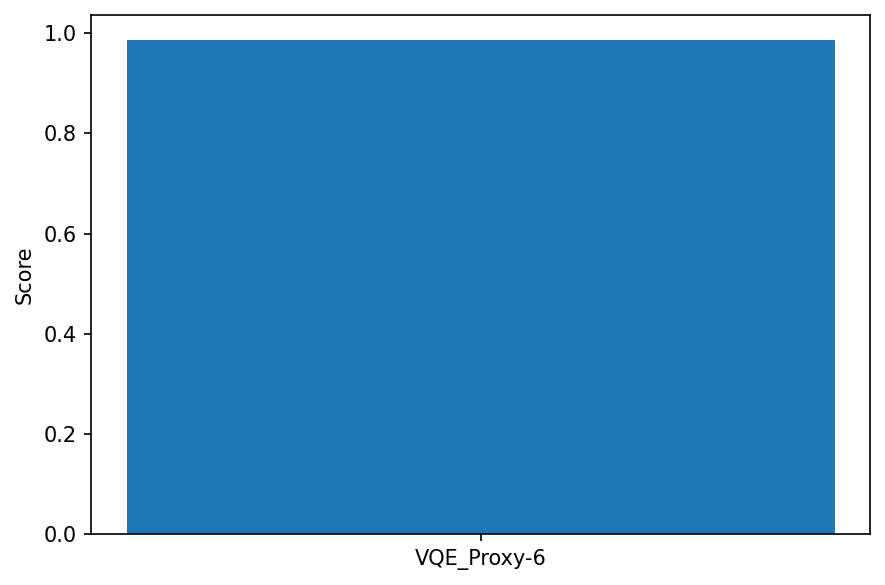

########################################################
 For circuit i=circuit-1180, execution time = 0.15361523628234863 sec and quantum time = 0.14447879791259766 sec
 For circuit i=circuit-1182, execution time = 0.15784072875976562 sec and quantum time = 0.14821171760559082 sec
Final Counts: [{'0000000': 595, '0000001': 43, '0000010': 41, '0000011': 11, '0000100': 43, '0000101': 3, '0000110': 11, '0000111': 3, '0001000': 44, '0001001': 3, '0001010': 2, '0001011': 0, '0001100': 3, '0001101': 0, '0001110': 1, '0001111': 0, '0010000': 43, '0010001': 3, '0010010': 3, '0010011': 0, '0010100': 3, '0010101': 0, '0010110': 0, '0010111': 0, '0011000': 3, '0011001': 0, '0011010': 0, '0011011': 0, '0011100': 0, '0011101': 0, '0011110': 0, '0011111': 0, '0100000': 42, '0100001': 3, '0100010': 3, '0100011': 0, '0100100': 3, '0100101': 0, '0100110': 0, '0100111': 0, '0101000': 3, '0101001': 0, '0101010': 0, '0101011': 0, '0101100': 0, '0101101': 0, '0101110': 0, '0101111': 0, '0110000': 3, '0110

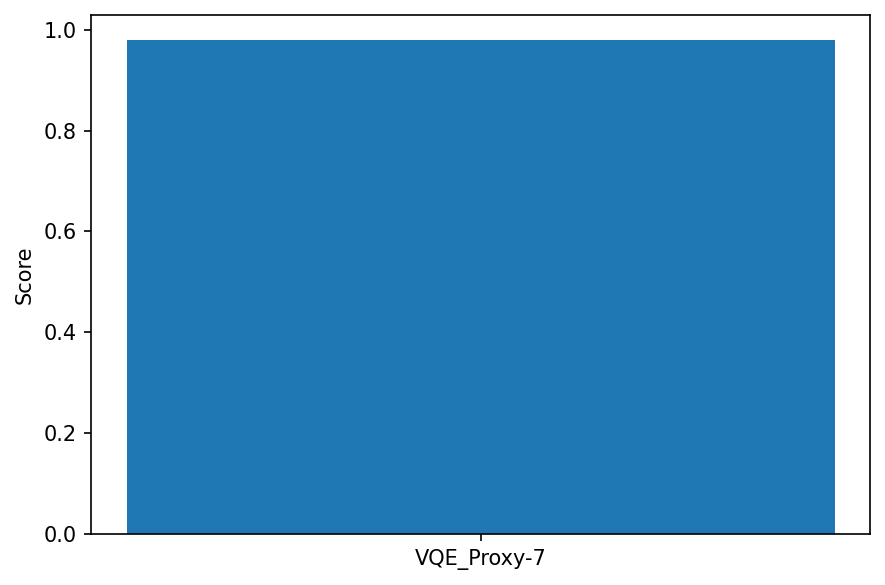

########################################################
 For circuit i=circuit-1305, execution time = 0.6756210327148438 sec and quantum time = 0.6662719249725342 sec
 For circuit i=circuit-1307, execution time = 0.7138564586639404 sec and quantum time = 0.7038464546203613 sec
Final Counts: [{'00000000': 544, '00000001': 38, '00000010': 38, '00000011': 10, '00000100': 38, '00000101': 3, '00000110': 10, '00000111': 1, '00001000': 37, '00001001': 2, '00001010': 2, '00001011': 0, '00001100': 10, '00001101': 0, '00001110': 1, '00001111': 0, '00010000': 37, '00010001': 2, '00010010': 2, '00010011': 0, '00010100': 2, '00010101': 0, '00010110': 0, '00010111': 0, '00011000': 9, '00011001': 0, '00011010': 0, '00011011': 0, '00011100': 1, '00011101': 0, '00011110': 0, '00011111': 0, '00100000': 39, '00100001': 2, '00100010': 2, '00100011': 0, '00100100': 2, '00100101': 0, '00100110': 0, '00100111': 0, '00101000': 3, '00101001': 0, '00101010': 0, '00101011': 0, '00101100': 0, '00101101': 0, '001

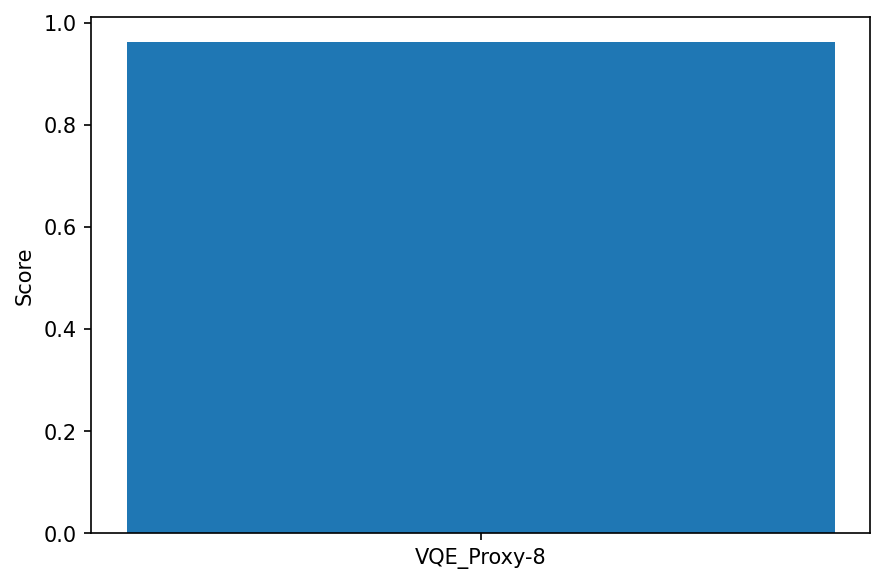

########################################################
 For circuit i=circuit-1446, execution time = 3.1849217414855957 sec and quantum time = 3.1751089096069336 sec
 For circuit i=circuit-1448, execution time = 2.865081310272217 sec and quantum time = 2.8539719581604004 sec
Final Counts: [{'000000000': 485, '000000001': 36, '000000010': 34, '000000011': 9, '000000100': 35, '000000101': 2, '000000110': 10, '000000111': 1, '000001000': 35, '000001001': 2, '000001010': 2, '000001011': 0, '000001100': 10, '000001101': 0, '000001110': 2, '000001111': 0, '000010000': 35, '000010001': 2, '000010010': 2, '000010011': 0, '000010100': 2, '000010101': 0, '000010110': 0, '000010111': 0, '000011000': 10, '000011001': 0, '000011010': 0, '000011011': 0, '000011100': 2, '000011101': 0, '000011110': 0, '000011111': 0, '000100000': 35, '000100001': 2, '000100010': 2, '000100011': 0, '000100100': 2, '000100101': 0, '000100110': 0, '000100111': 0, '000101000': 2, '000101001': 0, '000101010': 0, '000101

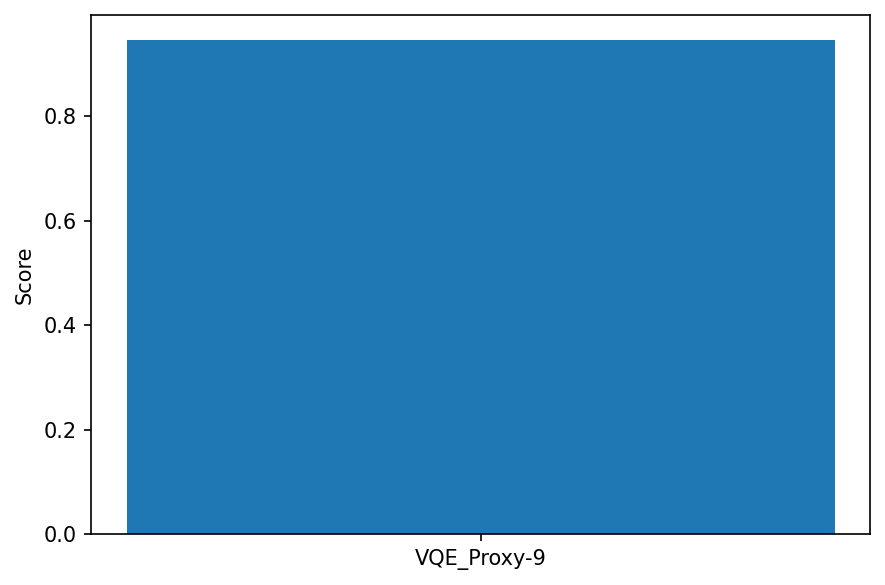

########################################################
 For circuit i=circuit-1603, execution time = 12.579024076461792 sec and quantum time = 12.568310499191284 sec
 For circuit i=circuit-1605, execution time = 12.840097665786743 sec and quantum time = 12.828603744506836 sec
Final Counts: [{'0000000000': 0, '0000000001': 0, '0000000010': 0, '0000000011': 0, '0000000100': 0, '0000000101': 0, '0000000110': 0, '0000000111': 0, '0000001000': 0, '0000001001': 0, '0000001010': 0, '0000001011': 0, '0000001100': 0, '0000001101': 0, '0000001110': 0, '0000001111': 0, '0000010000': 0, '0000010001': 0, '0000010010': 0, '0000010011': 0, '0000010100': 0, '0000010101': 0, '0000010110': 0, '0000010111': 0, '0000011000': 0, '0000011001': 0, '0000011010': 0, '0000011011': 0, '0000011100': 0, '0000011101': 0, '0000011110': 0, '0000011111': 0, '0000100000': 0, '0000100001': 0, '0000100010': 0, '0000100011': 0, '0000100100': 0, '0000100101': 0, '0000100110': 0, '0000100111': 0, '0000101000': 0, '0000101

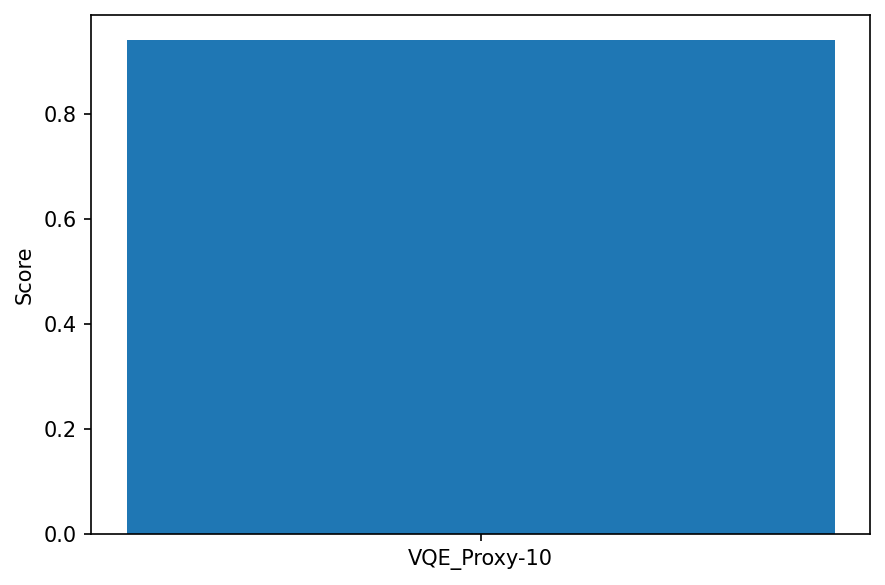

########################################################
 For circuit i=circuit-1776, execution time = 53.46856141090393 sec and quantum time = 53.45743417739868 sec
 For circuit i=circuit-1778, execution time = 54.53597378730774 sec and quantum time = 54.522757053375244 sec
Final Counts: [{'00000000000': 124, '00000000001': 13, '00000000010': 12, '00000000011': 8, '00000000100': 11, '00000000101': 1, '00000000110': 9, '00000000111': 4, '00000001000': 12, '00000001001': 1, '00000001010': 1, '00000001011': 1, '00000001100': 14, '00000001101': 1, '00000001110': 7, '00000001111': 3, '00000010000': 12, '00000010001': 1, '00000010010': 1, '00000010011': 0, '00000010100': 1, '00000010101': 0, '00000010110': 1, '00000010111': 0, '00000011000': 14, '00000011001': 1, '00000011010': 1, '00000011011': 1, '00000011100': 11, '00000011101': 1, '00000011110': 6, '00000011111': 2, '00000100000': 11, '00000100001': 1, '00000100010': 1, '00000100011': 0, '00000100100': 1, '00000100101': 0, '00000100110'

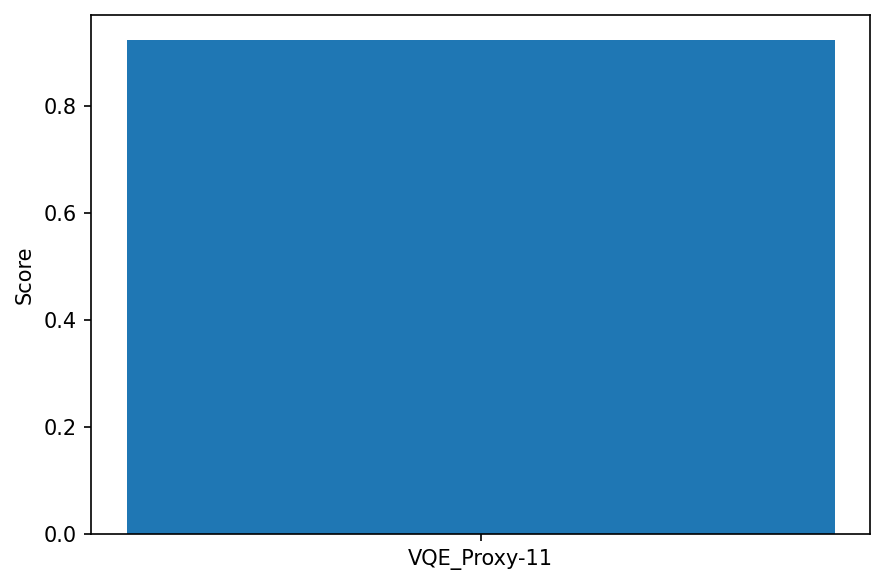

########################################################
 For circuit i=circuit-1965, execution time = 221.8356809616089 sec and quantum time = 221.82356667518616 sec
 For circuit i=circuit-1967, execution time = 222.22104454040527 sec and quantum time = 222.2020537853241 sec
Final Counts: [{'000000000000': 392, '000000000001': 27, '000000000010': 29, '000000000011': 7, '000000000100': 28, '000000000101': 2, '000000000110': 9, '000000000111': 1, '000000001000': 28, '000000001001': 2, '000000001010': 2, '000000001011': 0, '000000001100': 9, '000000001101': 0, '000000001110': 1, '000000001111': 0, '000000010000': 29, '000000010001': 2, '000000010010': 2, '000000010011': 0, '000000010100': 2, '000000010101': 0, '000000010110': 0, '000000010111': 0, '000000011000': 9, '000000011001': 0, '000000011010': 0, '000000011011': 0, '000000011100': 1, '000000011101': 0, '000000011110': 0, '000000011111': 0, '000000100000': 27, '000000100001': 2, '000000100010': 2, '000000100011': 0, '000000100100':

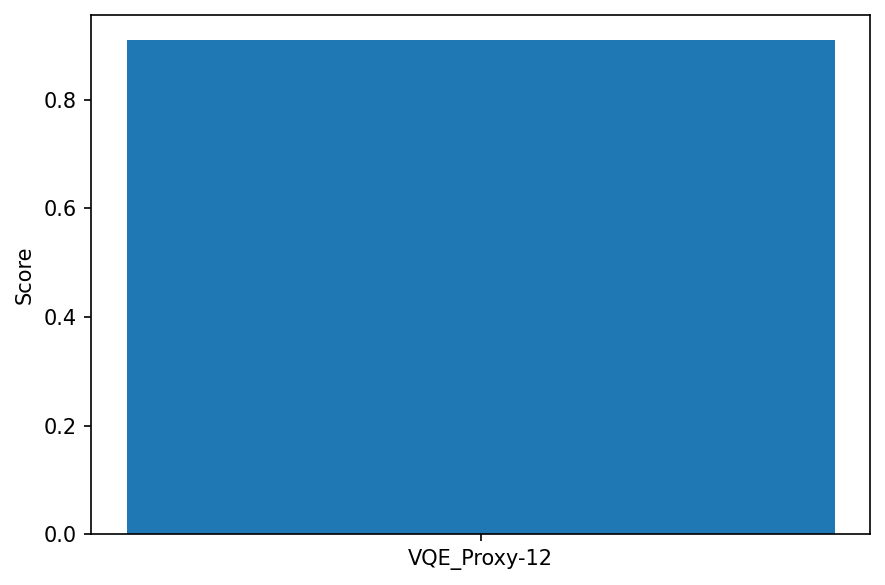

########################################################
 For circuit i=circuit-2170, execution time = 903.8652534484863 sec and quantum time = 903.8528053760529 sec
 For circuit i=circuit-2172, execution time = 905.6170129776001 sec and quantum time = 905.5898747444153 sec
Final Counts: [{'0000000000000': 383, '0000000000001': 30, '0000000000010': 30, '0000000000011': 11, '0000000000100': 27, '0000000000101': 2, '0000000000110': 7, '0000000000111': 1, '0000000001000': 25, '0000000001001': 2, '0000000001010': 2, '0000000001011': 0, '0000000001100': 11, '0000000001101': 0, '0000000001110': 2, '0000000001111': 0, '0000000010000': 22, '0000000010001': 1, '0000000010010': 1, '0000000010011': 0, '0000000010100': 1, '0000000010101': 0, '0000000010110': 0, '0000000010111': 0, '0000000011000': 5, '0000000011001': 0, '0000000011010': 0, '0000000011011': 0, '0000000011100': 2, '0000000011101': 0, '0000000011110': 0, '0000000011111': 0, '0000000100000': 30, '0000000100001': 2, '0000000100010': 2,

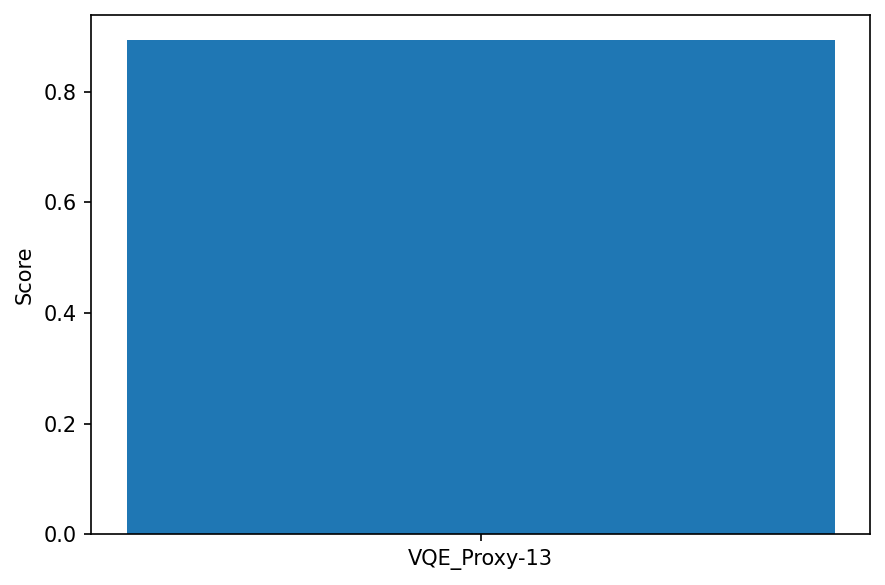

########################################################
 For circuit i=circuit-2391, execution time = 3986.247368335724 sec and quantum time = 3986.2344782352448 sec
 For circuit i=circuit-2393, execution time = 4090.4517323970795 sec and quantum time = 4090.346357345581 sec
Final Counts: [{'00000000000000': 0, '00000000000001': 0, '00000000000010': 0, '00000000000011': 0, '00000000000100': 0, '00000000000101': 0, '00000000000110': 0, '00000000000111': 0, '00000000001000': 0, '00000000001001': 0, '00000000001010': 0, '00000000001011': 0, '00000000001100': 0, '00000000001101': 0, '00000000001110': 0, '00000000001111': 0, '00000000010000': 0, '00000000010001': 0, '00000000010010': 0, '00000000010011': 0, '00000000010100': 0, '00000000010101': 0, '00000000010110': 0, '00000000010111': 0, '00000000011000': 0, '00000000011001': 0, '00000000011010': 0, '00000000011011': 0, '00000000011100': 0, '00000000011101': 0, '00000000011110': 0, '00000000011111': 0, '00000000100000': 0, '0000000010000

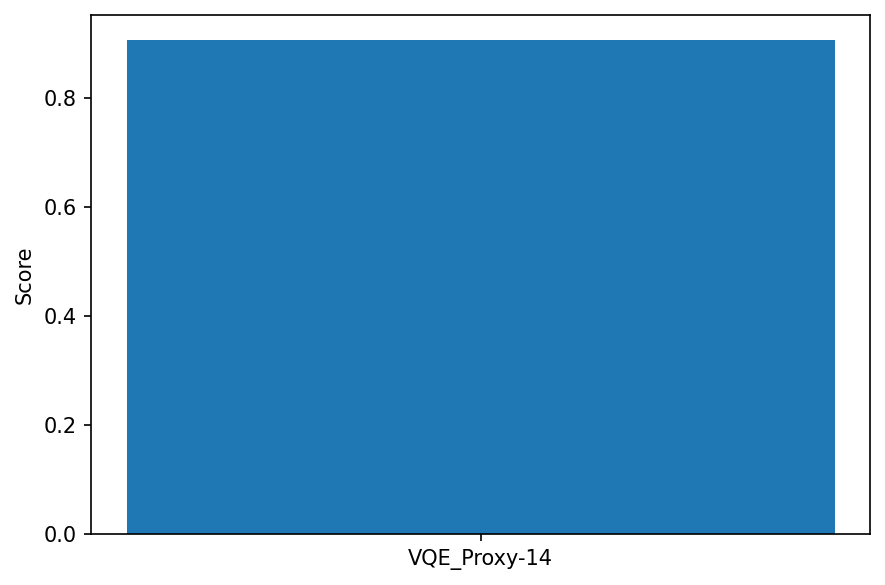

########################################################


In [ ]:
import simulation,time

def VQEP(qubits,l):
    
    name = "VQE_Proxy"
    final_counts = []
    ckt_list = []
    execution_times = []
    quantum_times = []
    
    # Calculate Creation time 
    t_c = time.time()
    #vqe = VQEProxy(3, 1) #3 Qubits, 1 Layer
    vqe = VQEProxy(qubits, l)
    shots = 1000
    ckts =  vqe.circuit()
    creation_time = time.time()-t_c
    
    for i in ckts:
        ckt_list.append(cirq_to_qiskit(i))
    
    #print(f" Creation time for {len(ckt_list)} circuits = {creation_time} sec")
    
    # for i in ckts:
    #     print(i)
    
    for i in ckt_list:
        t_e = time.time()
        job = execute(i, backend, shots=shots, **options)
        result = job.result()
        execution_time = time.time() - t_e #in sec
    
        # Calculate quantum processing time 
        quantum_time = (result.time_taken) #in sec
    
        #print(f" For circuit i, execution time = {execution_time} sec and quantum time = {quantum_time} sec")
        
        counts = result.results[0].data.partial_probability
        for key in counts.keys():
            counts[key] = int(counts[key] * shots)
    
        print(f" For circuit i={i.name}, execution time = {execution_time} sec and quantum time = {quantum_time} sec")
    
        final_counts.append(counts)
        execution_times.append(execution_time)
        quantum_times.append(quantum_time)
    print("Final Counts:",final_counts)
    qubits = vqe.num_qubits
    print(f"for {len(ckt_list)} circuits of {qubits} qubits Creation time = {creation_time} sec, Execution time = {sum(execution_times)} sec and quantum time = {sum(quantum_times)} sec")
    
    score_vqe = vqe.score(final_counts)
    print(score_vqe)
    
    
    benchmark_name = f"{name}-{qubits}"
    plot_results([score_vqe],[benchmark_name])
    
    print("########################################################")

    # #Features = dict()
        
    # for i in ckt_list:
    #     features = [
    #     compute_communication_with_qiskit(i),
    #     compute_depth_with_qiskit(i),
    #     compute_entanglement_with_qiskit(i),
    #     compute_liveness_with_qiskit(i),
    #     compute_measurement_with_qiskit(i),
    #     compute_parallelism_with_qiskit(i),
    #     ]
    #     print(f"Features for ckt {i.name}: {features}")
    #     Features[str(name)+{i.name}] = features
    #     plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
    #                        spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )
    
    # vqe_label = str(name)+"_"+str(qubits)
    # vqe_features = Features
    # vqe_score = score_vqe

if __name__=="__main__":
    for i in range(3,21):
        VQEP(i,1)